## STEP 1: Import Libraries (Credit Risk Scoring)

Import all required libraries for building a credit risk classification model.

This includes:

- Data manipulation (pandas, numpy)
- Data visualization (matplotlib, seaborn)
- Machine learning models (Logistic Regression, Random Forest, Gradient Boosting)
- Model evaluation tools (accuracy, ROC-AUC, confusion matrix, classification report)
- Preprocessing tools (Label Encoding, StandardScaler)
- Handling class imbalance using SMOTE

These libraries provide the foundation for predicting credit risk (e.g., good vs bad credit customers).

In [2]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn: preprocessing ---
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- Evaluation ---
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay
)

# --- Imbalanced data handling ---
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✔ Credit Risk libraries imported successfully.")

✔ Credit Risk libraries imported successfully.


## STEP 2: Load and Inspect Dataset

Load the credit risk dataset and perform an initial inspection.

This step includes:

- Loading the dataset using pandas
- Checking dataset shape (rows and columns)
- Viewing the first few records
- Checking data types of all columns

This helps understand the structure of the dataset before performing preprocessing and modeling.

In [3]:
df = pd.read_csv('/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv')

print(df.shape)        
print(df.head())
print(df.dtypes)

(32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                   

## STEP 3: Exploratory Data Analysis (EDA)

Perform exploratory data analysis to understand patterns in credit risk data and relationships between features and loan status.

This step includes:

- Generating basic statistical summary of numerical features
- Checking missing values in the dataset
- Visualizing class distribution of loan status
- Creating a correlation heatmap for numeric features
- Analyzing feature distributions using box plots based on loan status

EDA helps identify important patterns such as how income, loan amount, and age differ between good and bad loan applicants.

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

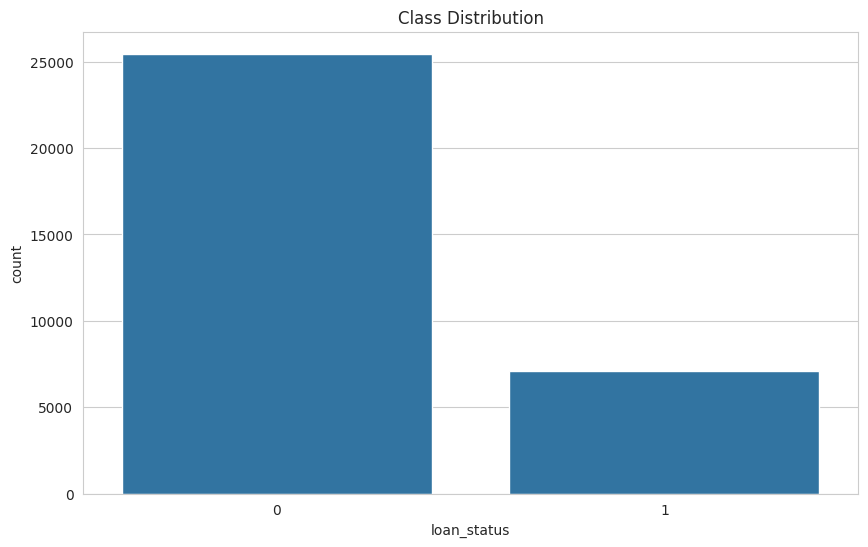

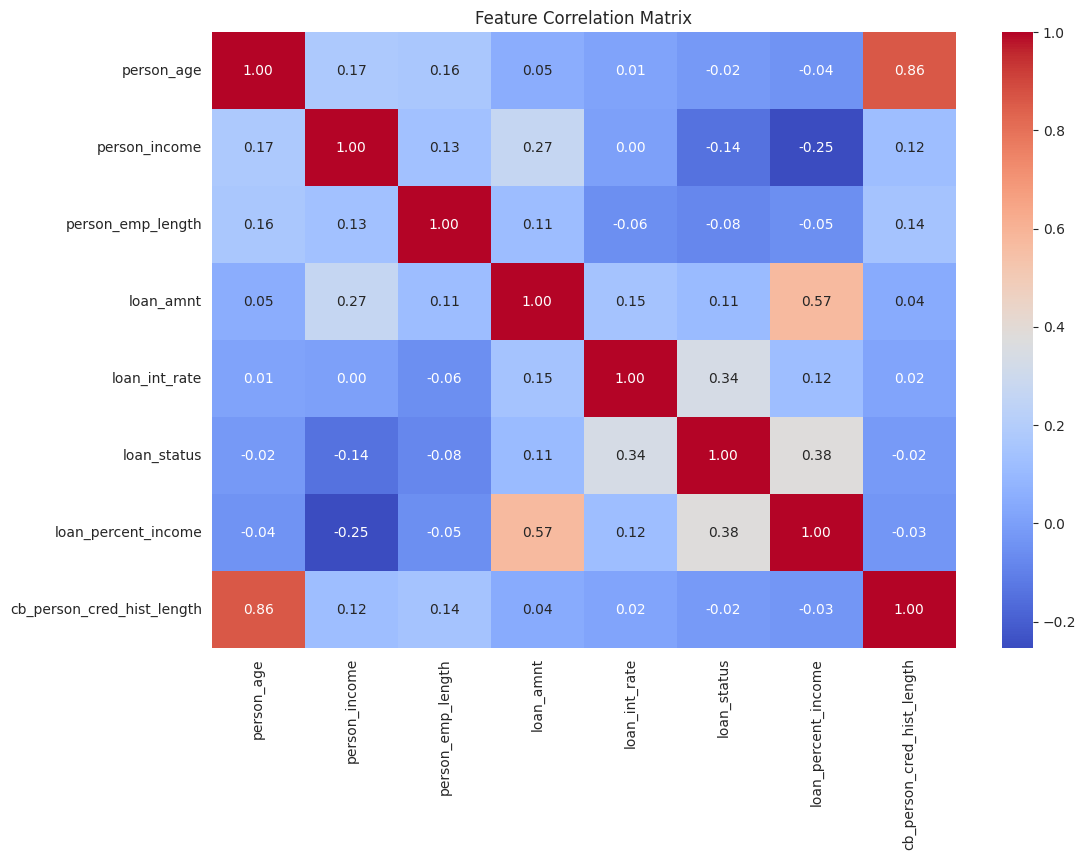

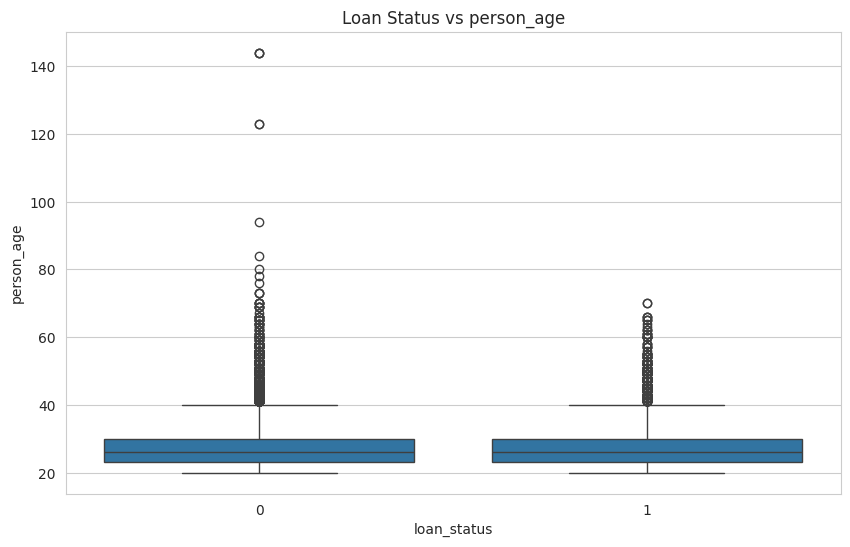

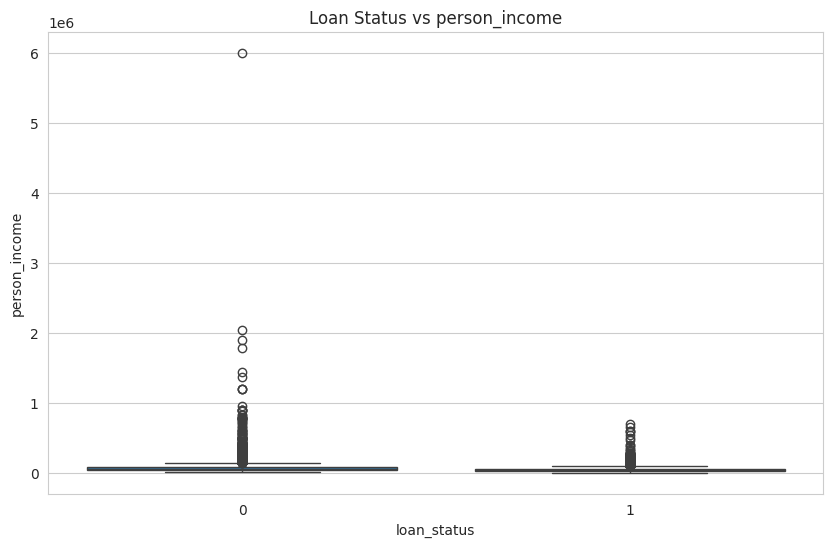

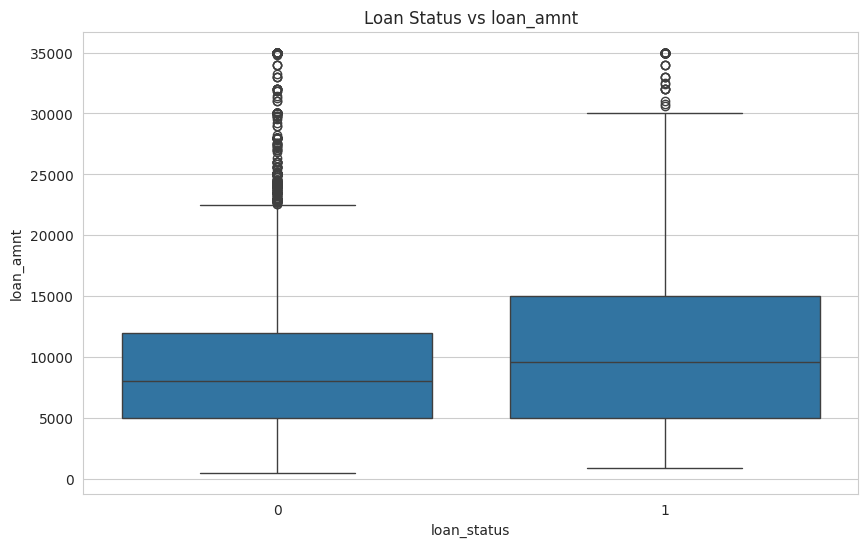

In [4]:
# Basic stats
print(df.describe())
print(df.isnull().sum())

# Class distribution
sns.countplot(x='loan_status', data=df)
plt.title('Class Distribution')
plt.show()

# Correlation heatmap (numeric columns)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Feature distributions by loan status
features_to_plot = ['person_age', 'person_income', 'loan_amnt']

for feat in features_to_plot:
    sns.boxplot(x='loan_status', y=feat, data=df)
    plt.title(f'Loan Status vs {feat}')
    plt.show()

## STEP 4: Data Preprocessing

Clean and prepare the dataset for machine learning by handling missing values and encoding categorical variables.

This step includes:

- Removing unnecessary index column (`Unnamed: 0`) if present
- Handling missing values:
  - Filling `loan_int_rate` with mean value
  - Filling `person_emp_length` with median value
- Ensuring the target variable (`loan_status`) is already numeric
- Encoding all remaining categorical features using Label Encoding

After this step, the dataset becomes fully numerical and ready for model training.

In [5]:
# Drop unnamed index column if present
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# Fill missing values
df['loan_int_rate'].fillna(df['loan_int_rate'].mean(), inplace=True)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

# Target column already numeric (0 = low risk, 1 = high risk)
# loan_status is already encoded

# Label encode all remaining categorical columns
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(df.dtypes)
print(df.head())

person_age                      int64
person_income                   int64
person_home_ownership           int64
person_emp_length             float64
loan_intent                     int64
loan_grade                      int64
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file       int64
cb_person_cred_hist_length      int64
dtype: object
   person_age  person_income  person_home_ownership  person_emp_length  \
0          22          59000                      3              123.0   
1          21           9600                      2                5.0   
2          25           9600                      0                1.0   
3          23          65500                      3                4.0   
4          24          54400                      3                8.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_status  \
0            4  

## STEP 5: Feature Engineering and Target Preparation

Create meaningful features and separate input features from the target variable.

This step includes:

### Feature Engineering:
- Creating a new feature `loan_percent_income` to represent loan burden relative to income
- Creating `age_group` by binning `person_age` into meaningful categories:
  - Young (0–25)
  - Adult (25–35)
  - Middle-aged (35–50)
  - Senior (50+)
- Handling missing values in `age_group`

### Data Preparation:
- Splitting dataset into features (X) and target variable (loan_status)
- Checking feature shape and class distribution

These transformations help improve model performance by adding meaningful financial risk indicators.

In [6]:
# Derived features
df['loan_percent_income'] = df['loan_amnt'] / df['person_income']

df['age_group'] = pd.cut(
    df['person_age'],
    bins=[0, 25, 35, 50, 100],
    labels=[0, 1, 2, 3]
)

df['age_group'] = df['age_group'].fillna(0).astype(int)

# Split features and target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (32581, 12)
Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


## STEP 6: Train-Test Split and Handling Class Imbalance (SMOTE)

Split the dataset into training and testing sets and handle class imbalance using SMOTE.

This step includes:

- Splitting the dataset into training and testing sets using an 80/20 ratio
- Using stratification to maintain the same class distribution in both sets
- Applying SMOTE (Synthetic Minority Oversampling Technique) **only on the training data**
- Generating synthetic samples for the minority class to balance the dataset

### Important:
SMOTE is applied only on the training set to avoid data leakage from the test set.

Finally, the class distribution before and after SMOTE is checked to confirm balancing.

In [7]:
from imblearn.over_sampling import SMOTE

# Train-test split BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 20378, 1: 5686}
After SMOTE : {0: 20378, 1: 20378}


## STEP 7: Feature Scaling

Normalize numerical features to ensure all variables are on the same scale.

This step includes:

- Applying `StandardScaler` to standardize feature values
- Fitting the scaler only on the resampled training data
- Transforming both training and test sets using the same scaler

### Why scaling is important:
Scaling ensures that features with large numeric ranges do not dominate the model, especially for algorithms like Logistic Regression and Gradient Boosting.

Finally, the shapes of the scaled training and testing datasets are checked.

In [8]:
scaler = StandardScaler()

# Fit on resampled train data, transform both sets
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (40756, 12)
Test shape : (6517, 12)


## STEP 8: Model Training and Evaluation

Train multiple classification models and evaluate their performance on the credit risk dataset.

This step includes:

- Training three machine learning models:
  - Logistic Regression
  - Random Forest Classifier
  - Gradient Boosting Classifier

- Using the scaled training data for model fitting
- Predicting outcomes on the test set
- Calculating predicted probabilities for ROC-AUC evaluation
- Evaluating models using:
  - Accuracy
  - ROC-AUC Score
  - Classification Report (Precision, Recall, F1-score)

### Key Idea:
ROC-AUC is an important metric for credit risk problems because it evaluates how well the model distinguishes between good and bad credit cases, especially in imbalanced datasets.

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train_res)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_prob),
        'report'  : classification_report(y_test, y_pred),
    }

    print(f"\n=== {name} ===")
    print("Accuracy:", round(results[name]['accuracy'], 4))
    print("ROC-AUC :", round(results[name]['roc_auc'], 4))
    print(results[name]['report'])


=== Logistic Regression ===
Accuracy: 0.78
ROC-AUC : 0.8358
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      5095
           1       0.50      0.72      0.59      1422

    accuracy                           0.78      6517
   macro avg       0.70      0.76      0.72      6517
weighted avg       0.82      0.78      0.79      6517


=== Random Forest ===
Accuracy: 0.9023
ROC-AUC : 0.92
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      5095
           1       0.79      0.75      0.77      1422

    accuracy                           0.90      6517
   macro avg       0.86      0.85      0.85      6517
weighted avg       0.90      0.90      0.90      6517


=== Gradient Boosting ===
Accuracy: 0.8895
ROC-AUC : 0.9102
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      5095
           1       0.75      0.74      0.75      1422

    a

## STEP 9: Model Evaluation and Visualization

Evaluate the best-performing model (Random Forest) using detailed performance metrics and visualizations.

This step includes:

### 1. Confusion Matrix
- Displays correct vs incorrect predictions
- Helps understand how many loans were correctly classified as low or high risk

### 2. ROC Curve
- Evaluates model performance across different classification thresholds
- AUC score shows how well the model distinguishes between good and bad credit cases

### 3. Feature Importance
- Identifies the most influential features in predicting credit risk
- Helps in understanding key drivers of loan default risk

### Key Insight:
Random Forest is selected as the best model due to its strong performance and interpretability in financial risk prediction tasks.

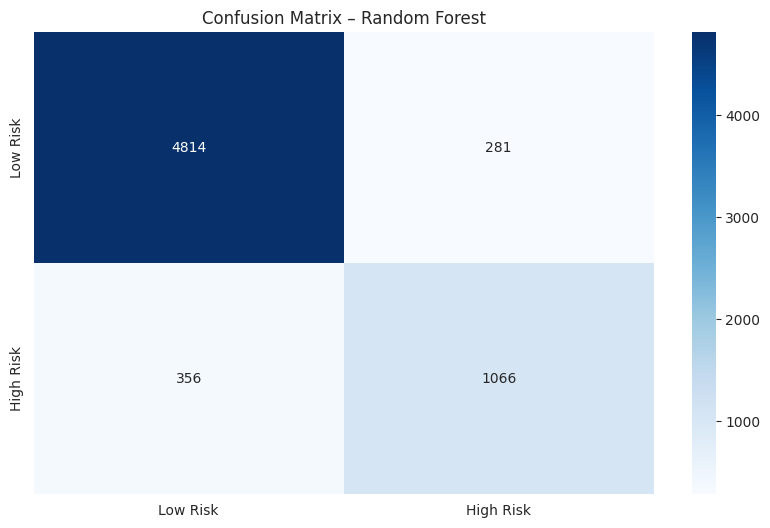

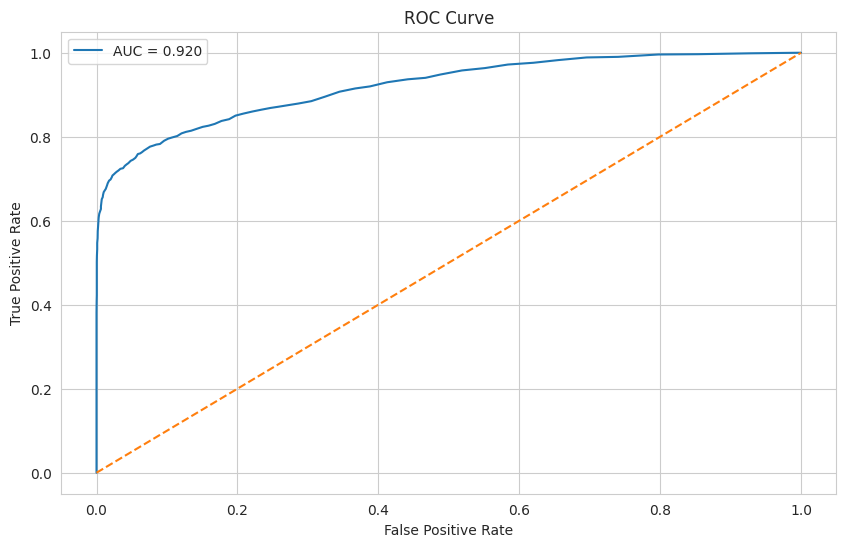

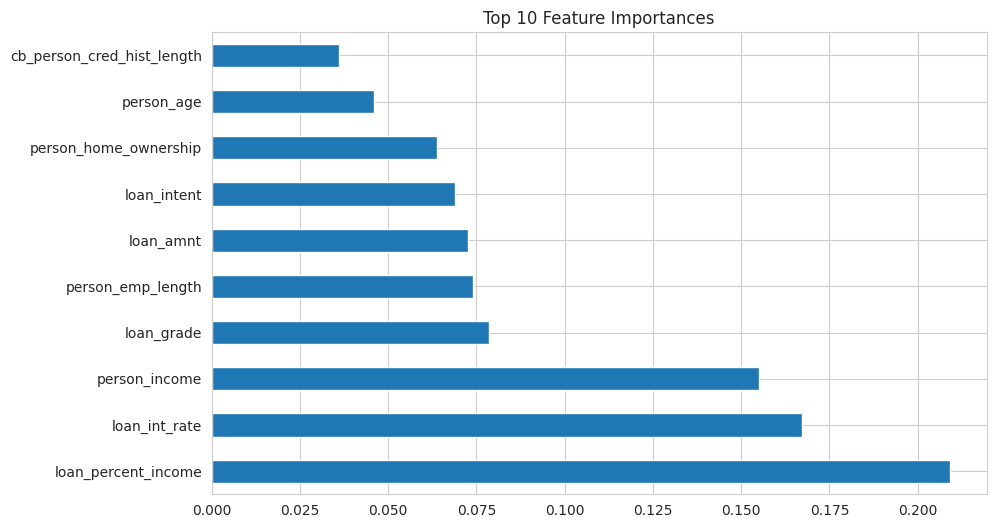

In [10]:
# Best model = Random Forest
best_model = models['Random Forest']

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk']
)

plt.title('Confusion Matrix – Random Forest')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)

feat_imp.nlargest(10).plot(kind='barh')

plt.title('Top 10 Feature Importances')
plt.show()

## STEP 10: Hyperparameter Tuning and Model Saving

Improve model performance using Grid Search and save the final trained model for deployment.

### Hyperparameter Tuning:
- GridSearchCV is used to find the best combination of parameters for Random Forest
- Parameters tuned include:
  - Number of trees (`n_estimators`)
  - Maximum tree depth (`max_depth`)
  - Minimum samples required to split a node (`min_samples_split`)
- Cross-validation (CV = 5) is used to ensure robust evaluation
- ROC-AUC is used as the scoring metric (important for imbalanced classification)

### Model Saving:
- The best model from Grid Search is saved using `joblib`
- The fitted scaler is also saved for consistent preprocessing during deployment

### Output:
- Best hyperparameters
- Best ROC-AUC score
- Saved model file: `credit_risk_model.pkl`
- Saved scaler file: `scaler.pkl`

In [11]:
# Grid Search for best parameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_res)

print("Best params:", grid_search.best_params_)
print("Best AUC  :", round(grid_search.best_score_, 4))

# Save the tuned model + scaler
import joblib

joblib.dump(grid_search.best_estimator_, 'credit_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved!")

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best AUC  : 0.9767
Model saved!
